In [ ]:
import pandas as pd
import numpy as np

path = "matriculaciones_departamentos_distritos_20260120 (2).csv"
df = pd.read_csv(path)

# Normalizar nombres por si hay variaciones de mayúsculas/minúsculas
df["nombre_zona"] = df["nombre_zona"].astype(str).str.strip()
df["sector_o_tipo_gestion"] = df["sector_o_tipo_gestion"].astype(str).str.strip()

df["h"] = pd.to_numeric(df["cantidad_matriculados_hombre"], errors="coerce").fillna(0)
df["m"] = pd.to_numeric(df["cantidad_matriculados_mujer"], errors="coerce").fillna(0)
df["total"] = df["h"] + df["m"]

df.head(), df.shape


(   anio  codigo_departamento nombre_departamento  codigo_distrito  \
 0  2023                   17       Alto Paraguay                4   
 1  2023                   17       Alto Paraguay                4   
 2  2023                   17       Alto Paraguay                4   
 3  2023                   17       Alto Paraguay                5   
 4  2023                   17       Alto Paraguay                5   
 
    nombre_distrito  codigo_zona nombre_zona sector_o_tipo_gestion  \
 0      Bahía Negra            1      Urbana               Oficial   
 1      Bahía Negra            2       Rural               Privado   
 2      Bahía Negra            2       Rural               Oficial   
 3  Carmelo Peralta            2       Rural               Oficial   
 4  Carmelo Peralta            1      Urbana               Oficial   
 
    anho_cod_geo  cantidad_matriculados_hombre  cantidad_matriculados_mujer  \
 0           NaN                           244                          205  

In [ ]:
from scipy.stats import entropy

group_cols = ["codigo_departamento","nombre_departamento","codigo_distrito","nombre_distrito"]

def entropia_contexto(sub):
    # Distribución de matrícula por (zona, sector)
    combos = sub.groupby(["nombre_zona","sector_o_tipo_gestion"])["total"].sum()
    if combos.sum() == 0:
        return 0.0
    p = (combos / combos.sum()).values
    return float(entropy(p, base=2))

rows = []
for keys, sub in df.groupby(group_cols):
    total = sub["total"].sum()
    h = sub["h"].sum()
    m = sub["m"].sum()

    # Suavizado para estabilidad numérica
    pct_mujeres = (m + 0.5) / (total + 1.0) if total > 0 else np.nan
    ratio_h_m = (h + 0.5) / (m + 0.5)

    urbana = sub.loc[sub["nombre_zona"].str.lower()=="urbana", "total"].sum()
    privado = sub.loc[sub["sector_o_tipo_gestion"].str.lower()=="privado", "total"].sum()

    rows.append((*keys,
                 total,
                 pct_mujeres,
                 ratio_h_m,
                 (urbana/total if total>0 else 0.0),
                 (privado/total if total>0 else 0.0),
                 entropia_contexto(sub)))

territ = pd.DataFrame(rows, columns=group_cols + [
    "matricula_total","pct_mujeres","ratio_h_m","share_urbana","share_privado","entropia_contexto"
])

territ.describe(include="all")


,codigo_departamento,nombre_departamento,codigo_distrito,nombre_distrito,matricula_total,pct_mujeres,ratio_h_m,share_urbana,share_privado,entropia_contexto
count,263.000000,263,263.000000,263,263.000000,263.000000,263.000000,263.000000,263.000000,263.000000
unique,NaN,18,NaN,261,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Itapúa,NaN,Bella Vista,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,30,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN
mean,7.692015,NaN,9.806084,NaN,5888.034221,0.494535,1.023895,0.486096,0.036201,1.123780
std,4.327285,NaN,6.399281,NaN,12347.822527,0.014759,0.060403,0.267556,0.061842,0.441236
min,0.000000,NaN,0.000000,NaN,144.000000,0.450000,0.796853,0.000000,0.000000,0.000000
25%,4.000000,NaN,5.000000,NaN,1201.000000,0.486826,0.991791,0.286710,0.000000,0.885088
50%,7.000000,NaN,9.000000,NaN,2375.000000,0.494887,1.020662,0.476080,0.006740,1.061676
75%,11.000000,NaN,14.000000,NaN,5269.000000,0.502061,1.054121,0.679697,0.046088,1.456074


In [ ]:
!pip -q install umap-learn

from sklearn.preprocessing import StandardScaler
import umap

features = ["matricula_total","pct_mujeres","ratio_h_m","share_urbana","share_privado","entropia_contexto"]

X = territ[features].replace([np.inf,-np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))

Xs = StandardScaler().fit_transform(X)

umap_model = umap.UMAP(
    n_neighbors=15,     # vecindad
    min_dist=0.05,      # compacidad visual
    n_components=2,
    random_state=42
)
emb = umap_model.fit_transform(Xs)

territ["u1"] = emb[:,0]
territ["u2"] = emb[:,1]
territ.head()


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


,codigo_departamento,nombre_departamento,codigo_distrito,nombre_distrito,matricula_total,pct_mujeres,ratio_h_m,share_urbana,share_privado,entropia_contexto,u1,u2
0,0,Capital,0,Asunción,131222,0.501402,0.994407,1.000000,0.309331,1.544217,5.768093,7.127777
1,1,Concepción,1,Concepción,21216,0.497078,1.011757,0.877262,0.042704,1.637785,5.045180,6.743084
2,1,Concepción,2,Belén,3364,0.473848,1.110379,0.225030,0.000000,0.769246,-1.121235,5.584830
3,1,Concepción,3,Horqueta,10989,0.499227,1.003099,0.393211,0.009919,1.486216,3.882280,4.608599
4,1,Concepción,4,Loreto,4028,0.487342,1.051948,0.445879,0.016634,1.093993,0.808021,4.269715


In [ ]:
!pip -q install hdbscan

import hdbscan

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=12,    # ajustable: 8–20 según estabilidad
    min_samples=8,          # más alto = más puntos como ruido
    metric="euclidean"
)

labels = clusterer.fit_predict(emb)
territ["cluster"] = labels
territ["prob_cluster"] = clusterer.probabilities_

territ["cluster"].value_counts().sort_index()


/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


,count
cluster,
-1,63
0,13
1,36
2,21
3,36
4,15
5,26
6,14
7,39


In [ ]:
from sklearn.neighbors import LocalOutlierFactor

# Opción 1 (recomendado): LOF en el espacio original escalado (interpretable por variables)
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)  # 5% outliers (ajustable)
pred = lof.fit_predict(Xs)
score = -lof.negative_outlier_factor_  # más alto = más atípico

territ["lof_outlier"] = (pred == -1).astype(int)
territ["lof_score"] = score

territ.sort_values("lof_score", ascending=False).head(15)[
    ["nombre_departamento","nombre_distrito","cluster","lof_score","matricula_total","share_urbana","share_privado","pct_mujeres"]
]


,nombre_departamento,nombre_distrito,cluster,lof_score,matricula_total,share_urbana,share_privado,pct_mujeres
0,Capital,Asunción,2,3.817797,131222,1.000000,0.309331,0.501402
166,Alto Paraná,Ciudad del Este,2,2.588003,90591,0.999746,0.198607,0.517645
253,Presidente Hayes,Campo Aceval,-1,2.348668,1230,0.000000,0.385366,0.500812
74,Guairá,Tebicuary,3,2.174121,627,0.727273,0.000000,0.556529
14,Concepción,Itacuá,-1,2.137037,688,0.000000,0.000000,0.527576
228,Amambay,Cerro Corá,7,1.997899,2333,0.000000,0.000000,0.515638
146,Misiones,Villa Florida,1,1.870433,786,1.000000,0.000000,0.482211
36,San Pedro,San José del Rosario,7,1.847180,862,0.000000,0.112529,0.488413
257,Boquerón,Loma Plata,4,1.816482,6043,0.467979,0.340063,0.498097
5,Concepción,San Carlos del Apa,-1,1.750157,185,1.000000,0.000000,0.497312


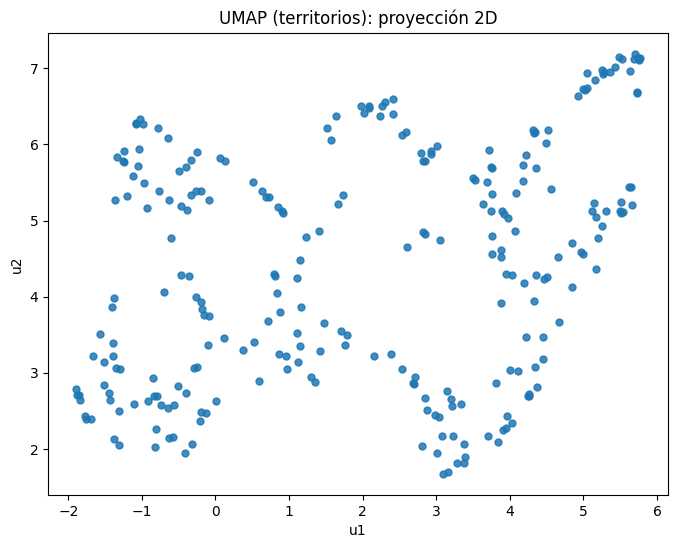

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(territ["u1"], territ["u2"], s=25, alpha=0.85)
plt.title("UMAP (territorios): proyección 2D")
plt.xlabel("u1"); plt.ylabel("u2")
plt.show()


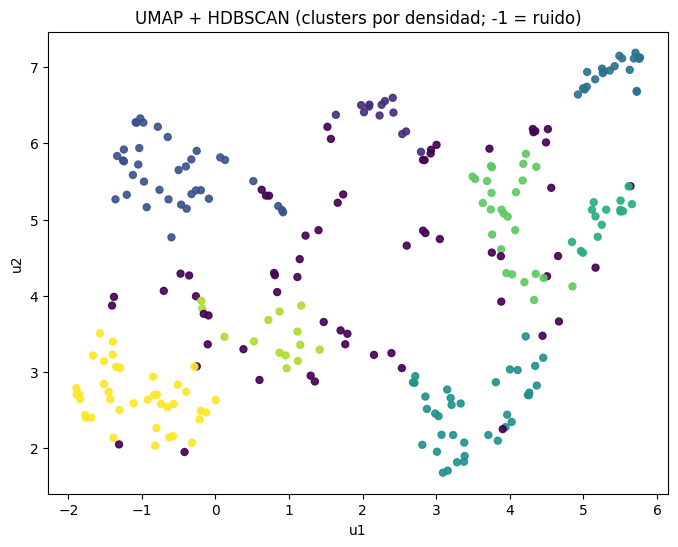

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(territ["u1"], territ["u2"], c=territ["cluster"], s=25, alpha=0.9)
plt.title("UMAP + HDBSCAN (clusters por densidad; -1 = ruido)")
plt.xlabel("u1"); plt.ylabel("u2")
plt.show()


In [ ]:
perfil = territ[features + ["cluster"]].groupby("cluster").agg(["mean","median","count"])
perfil


matricula_total                pct_mujeres                 ratio_h_m  \
                   mean   median count        mean    median count      mean   
cluster                                                                        
-1          2839.095238   1761.0    63    0.493914  0.491140    63  1.025577   
 0          2627.384615   2209.0    13    0.477664  0.477781    13  1.093777   
 1          1664.527778   1170.0    36    0.473128  0.475376    36  1.114497   
 2         35904.476190  27466.0    21    0.496632  0.497078    21  1.013942   
 3          2004.500000   1605.0    36    0.516082  0.514498    36  0.938364   
 4          3178.800000   2704.0    15    0.502912  0.502393    15  0.988612   
 5          8773.384615   6987.5    26    0.496463  0.495901    26  1.014595   
 6          2976.428571   3111.5    14    0.493921  0.494210    14  1.024697   
 7          3384.487179   2612.0    39    0.495616  0.495997    39  1.018044   

                        share_urbana                 share_privado            \
           median count         mean    median count          mean    median   
cluster                                                                        
-1       1.036080    63     0.498464  0.501318    63      0.032759  0.014902   
 0       1.093009    13     0.552656  0.519692    13      0.017816  0.000000   
 1       1.103599    36     0.415935  0.375887    36      0.001554  0.000000   
 2       1.011757    21     0.917771  0.995753    21      0.137470  0.119210   
 3       0.943644    36     0.617153  0.648658    36      0.014667  0.000000   
 4       0.990474    15     0.596413  0.602781    15      0.150733  0.124740   
 5       1.016533    26     0.487962  0.486606    26      0.040359  0.034521   
 6       1.023443    14     0.424954  0.434136    14      0.000755  0.000000   
 7       1.016142    39     0.133553  0.145478    39      0.011119  0.000000   

              entropia_contexto                  
        count              mean    median count  
cluster                                          
-1         63          1.152727  1.119572    63  
 0         13          1.499208  1.471248    13  
 1         36          0.841463  0.885088    36  
 2         21          1.301655  1.375393    21  
 3         36          1.114721  1.030340    36  
 4         15          1.588694  1.510415    15  
 5         26          1.677531  1.651233    26  
 6         14          1.049560  1.024385    14  
 7         39          0.603724  0.684719    39

In [ ]:
top_out = territ.sort_values("lof_score", ascending=False).head(10)
top_out[["nombre_departamento","nombre_distrito","cluster","lof_score"] + features]


,nombre_departamento,nombre_distrito,cluster,lof_score,matricula_total,pct_mujeres,ratio_h_m,share_urbana,share_privado,entropia_contexto
0,Capital,Asunción,2,3.817797,131222,0.501402,0.994407,1.000000,0.309331,1.544217
166,Alto Paraná,Ciudad del Este,2,2.588003,90591,0.517645,0.931826,0.999746,0.198607,0.928052
253,Presidente Hayes,Campo Aceval,-1,2.348668,1230,0.500812,0.996756,0.000000,0.385366,1.070098
74,Guairá,Tebicuary,3,2.174121,627,0.556529,0.796853,0.727273,0.000000,0.845351
14,Concepción,Itacuá,-1,2.137037,688,0.527576,0.895461,0.000000,0.000000,0.000000
228,Amambay,Cerro Corá,7,1.997899,2333,0.515638,0.939344,0.000000,0.000000,0.000000
146,Misiones,Villa Florida,1,1.870433,786,0.482211,1.073781,1.000000,0.000000,0.000000
36,San Pedro,San José del Rosario,7,1.847180,862,0.488413,1.047450,0.000000,0.112529,0.507497
257,Boquerón,Loma Plata,4,1.816482,6043,0.498097,1.007640,0.467979,0.340063,2.092898
5,Concepción,San Carlos del Apa,-1,1.750157,185,0.497312,1.010811,1.000000,0.000000,0.000000


In [ ]:
territ.to_csv("paper2_territorial_resultados.csv", index=False)
perfil.to_csv("paper2_territorial_perfil_clusters.csv")
top_out.to_csv("paper2_territorial_top_outliers.csv", index=False)

print("Listo: CSVs generados.")


Listo: CSVs generados.


In [ ]:
import zipfile
import os

# Asegurarnos que los archivos estén guardados
territ.to_csv("paper2_territorial_resultados.csv", index=False)
perfil.to_csv("paper2_territorial_perfil_clusters.csv")
top_out.to_csv("paper2_territorial_top_outliers.csv", index=False)

# También versión Excel (más cómodo para revisar)
with pd.ExcelWriter("paper2_territorial_resultados.xlsx") as writer:
    territ.to_excel(writer, sheet_name="Resultados_completos", index=False)
    perfil.to_excel(writer, sheet_name="Perfil_clusters")
    top_out.to_excel(writer, sheet_name="Top_outliers", index=False)

# Crear ZIP
zip_filename = "Paper2_Analisis_Territorial_UMAP_HDBSCAN_LOF.zip"

with zipfile.ZipFile(zip_filename, 'w') as zipf:
    zipf.write("paper2_territorial_resultados.csv")
    zipf.write("paper2_territorial_perfil_clusters.csv")
    zipf.write("paper2_territorial_top_outliers.csv")
    zipf.write("paper2_territorial_resultados.xlsx")

print("ZIP generado:", zip_filename)


ZIP generado: Paper2_Analisis_Territorial_UMAP_HDBSCAN_LOF.zip


In [ ]:
from google.colab import files
files.download("Paper2_Analisis_Territorial_UMAP_HDBSCAN_LOF.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>